# HOSPITAL EMERGENCY ROOM PERFORMANCE AND PREDICTION PROJECT

---------------------------------------------------

# PART 1 – DATA CLEANING AND PREPARATION

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

**Load Data**

In [48]:
df = pd.read_csv(r"C:\Users\choice laptops\Desktop\ER Wait Time Dataset.csv")
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


**Clean Column Names**

In [49]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print(df.columns)

Index(['visit_id', 'patient_id', 'hospital_id', 'hospital_name', 'region',
       'visit_date', 'day_of_week', 'season', 'time_of_day', 'urgency_level',
       'nurse-to-patient_ratio', 'specialist_availability',
       'facility_size_beds', 'time_to_registration_min', 'time_to_triage_min',
       'time_to_medical_professional_min', 'total_wait_time_min',
       'patient_outcome', 'patient_satisfaction'],
      dtype='object')


**Check Missing Values**

In [51]:
df.isnull().sum()

visit_id                            0
patient_id                          0
hospital_id                         0
hospital_name                       0
region                              0
visit_date                          0
day_of_week                         0
season                              0
time_of_day                         0
urgency_level                       0
nurse-to-patient_ratio              0
specialist_availability             0
facility_size_beds                  0
time_to_registration_min            0
time_to_triage_min                  0
time_to_medical_professional_min    0
total_wait_time_min                 0
patient_outcome                     0
patient_satisfaction                0
dtype: int64

In [52]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [53]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [56]:
print(df.columns)

Index(['visit_id', 'patient_id', 'hospital_id', 'hospital_name', 'region',
       'visit_date', 'day_of_week', 'season', 'time_of_day', 'urgency_level',
       'nurse-to-patient_ratio', 'specialist_availability',
       'facility_size_beds', 'time_to_registration_min', 'time_to_triage_min',
       'time_to_medical_professional_min', 'total_wait_time_min',
       'patient_outcome', 'patient_satisfaction'],
      dtype='object')


**Remove Duplicates**

In [57]:
df.drop_duplicates(inplace=True)

**Convert Date Column**

In [58]:
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')

**Create Time Features**

In [59]:
df['hour'] = df['visit_date'].dt.hour
df['month'] = df['visit_date'].dt.month
df['day_name'] = df['visit_date'].dt.day_name()

**Detect Outliers (IQR Method)**

In [60]:
Q1 = df['total_wait_time_min'].quantile(0.25)
Q3 = df['total_wait_time_min'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['total_wait_time_min'] >= Q1 - 1.5 * IQR) &
    (df['total_wait_time_min'] <= Q3 + 1.5 * IQR)
]

# PART 2 — EXPLORATORY DATA ANALYSIS

**Total Patients**

In [61]:
print("Total Patients:", df.shape[0])

Total Patients: 4916


**Average Waiting Time**

In [62]:
print("Average Waiting Time:", df['total_wait_time_min'].mean())

Average Waiting Time: 78.10984540276648


**Median Waiting Time**

In [63]:
print("Median Waiting Time:", df['total_wait_time_min'].median())

Median Waiting Time: 59.0


**Standard Deviation**

In [64]:
print("Std Dev:", df['total_wait_time_min'].std())

Std Dev: 61.86805551889616


# VISUALIZATIONS

**1 Waiting Time Distribution**

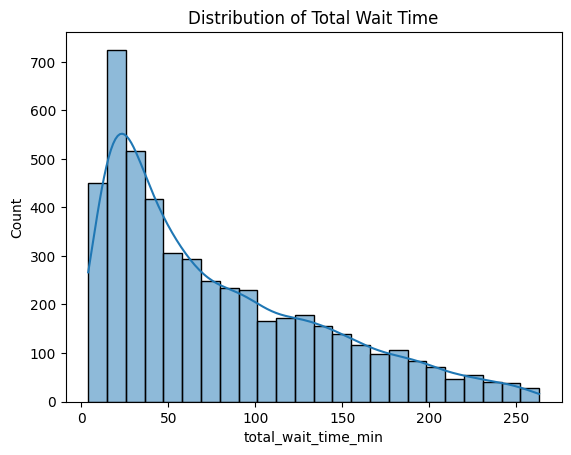

In [65]:
sns.histplot(df['total_wait_time_min'], kde=True)
plt.title("Distribution of Total Wait Time")
plt.show()

**2 Patients by Hour**

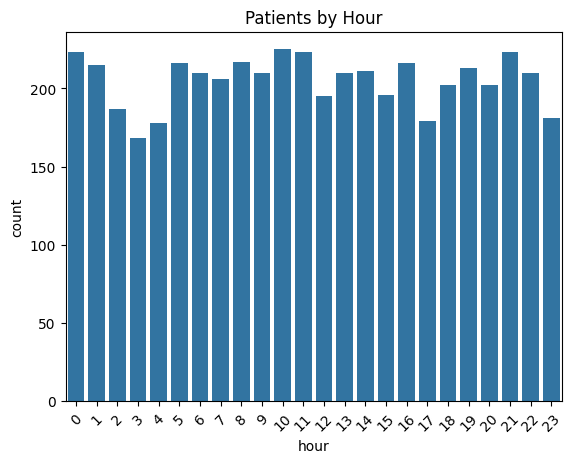

In [66]:
sns.countplot(x='hour', data=df)
plt.title("Patients by Hour")
plt.xticks(rotation=45)
plt.show()

**3 Patients by Day**

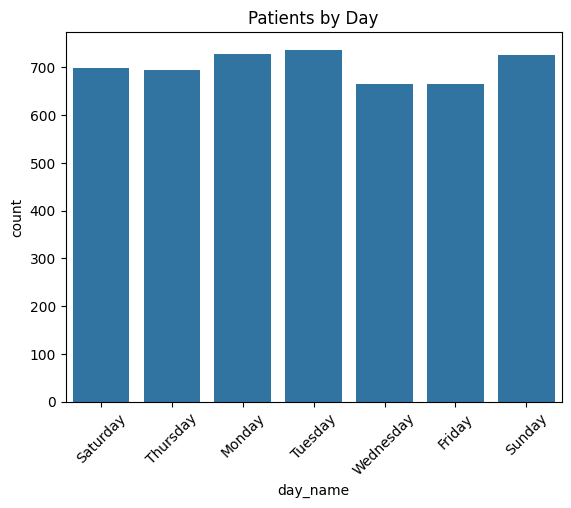

In [67]:
sns.countplot(x='day_name', data=df)
plt.title("Patients by Day")
plt.xticks(rotation=45)
plt.show()

**4 Waiting Time by Urgency Level**

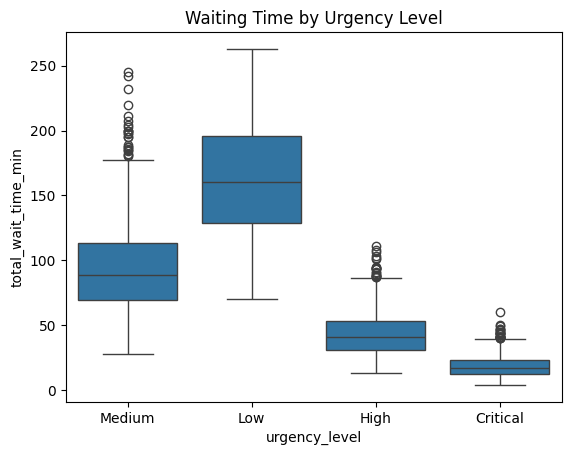

In [68]:
sns.boxplot(x='urgency_level', y='total_wait_time_min', data=df)
plt.title("Waiting Time by Urgency Level")
plt.show()

**5 Waiting Time by Region**

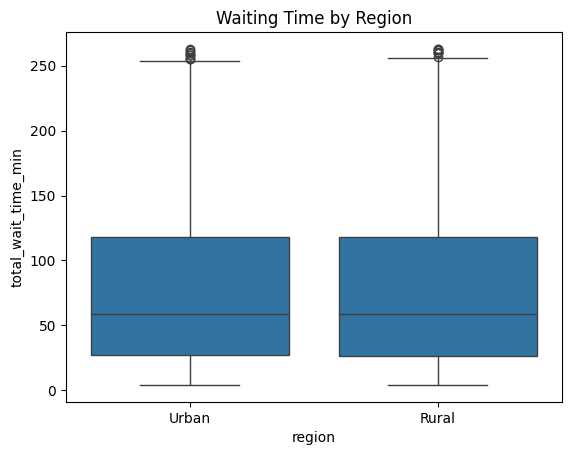

In [70]:
sns.boxplot(x='region', y='total_wait_time_min', data=df)
plt.title("Waiting Time by Region")
plt.show()

**6 Nurse-to-Patient Ratio vs Waiting Time**

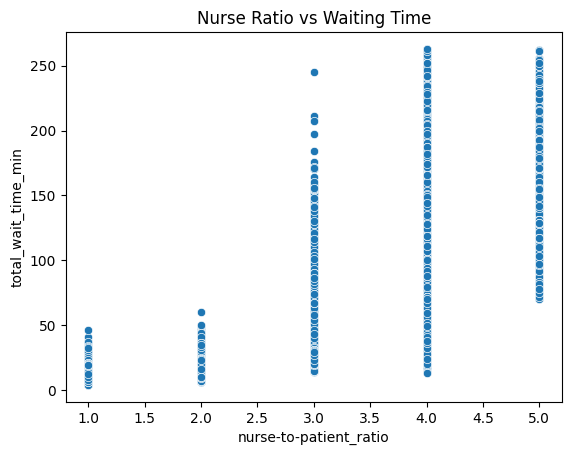

In [71]:
sns.scatterplot(x='nurse-to-patient_ratio', y='total_wait_time_min', data=df)
plt.title("Nurse Ratio vs Waiting Time")
plt.show()

**7 Specialist Availability Impact**

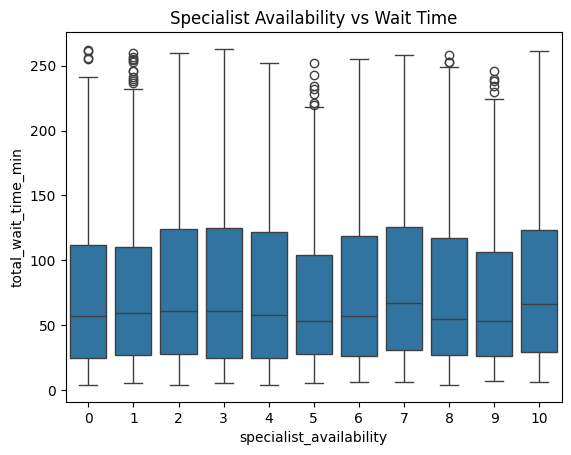

In [72]:
sns.boxplot(x='specialist_availability', y='total_wait_time_min', data=df)
plt.title("Specialist Availability vs Wait Time")
plt.show()

**8 Facility Size vs Waiting Time**

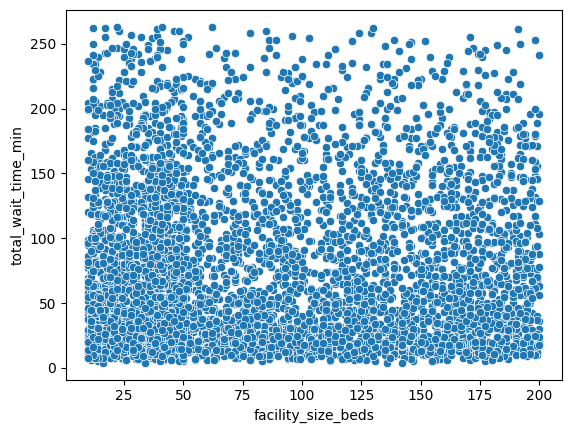

In [73]:
sns.scatterplot(x='facility_size_beds', y='total_wait_time_min', data=df)
plt.show()

**9 Correlation Heatmap**

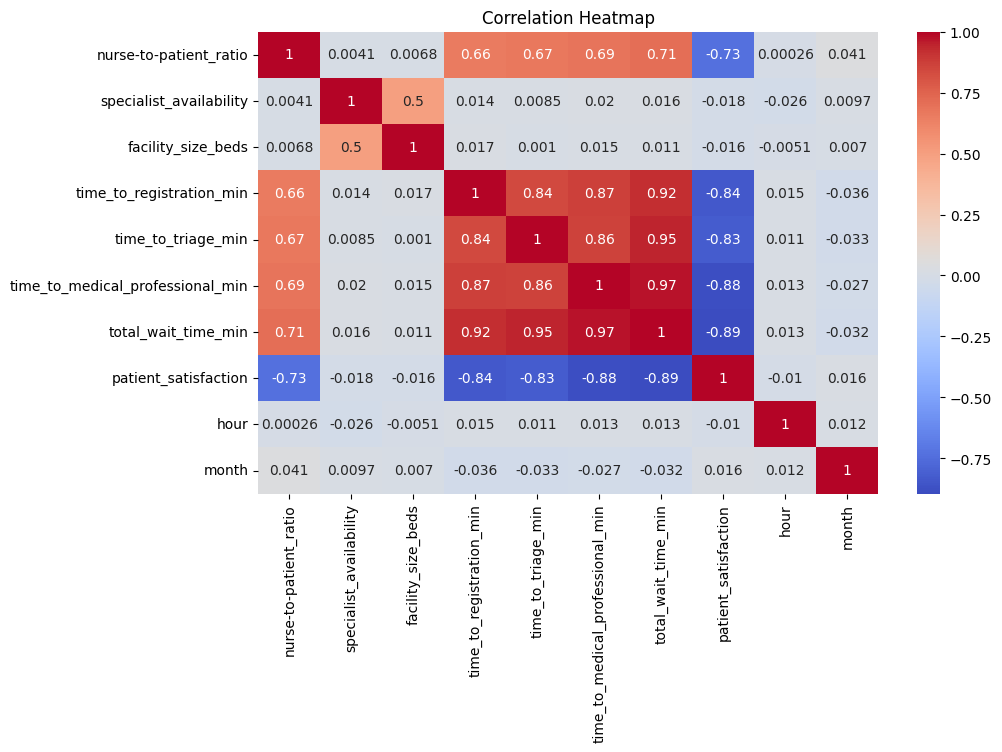

In [74]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# PART 3 — STATISTICAL REASONING

**Skewness**

In [75]:
print("Skewness:", df['total_wait_time_min'].skew())

Skewness: 0.9312528015046387


**Compare Urban vs Rural**

In [76]:
df.groupby('region')['total_wait_time_min'].mean()

region
Rural    77.351918
Urban    78.610267
Name: total_wait_time_min, dtype: float64

# PART 4 — FEATURE ENGINEERING

**Weekend Feature**

In [77]:
df['is_weekend'] = df['day_name'].isin(['Saturday','Sunday']).astype(int)

**Encode Categorical Variables**

In [78]:
df_model = pd.get_dummies(df, drop_first=True)

# PART 5 — MACHINE LEARNING

**Define X and y**

In [84]:
# Define target
y = df_model['total_wait_time_min']

# Drop target only
X = df_model.drop(columns=['total_wait_time_min'])

# Remove ID columns safely
id_columns = ['visit_id', 'patient_id', 'hospital_id', 'hospital_name']

X = X.drop(columns=[col for col in id_columns if col in X.columns])

**Train Test Split**

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model 1 — Linear Regression**

In [88]:
# Define target
y = df['total_wait_time_min']

# Define features
X = df.drop(columns=['total_wait_time_min'])

# Remove ID and datetime columns
X = X.drop(columns=['visit_id','patient_id','hospital_id','hospital_name','visit_date'], errors='ignore')

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Model 2 — Decision Tree**

In [89]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

**Model 3 — Random Forest**

In [90]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# PART 6 — MODEL EVALUATION

In [92]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2

print("Linear:", evaluate_model(lr, X_test, y_test))

Linear: (1.881692633687857e-14, np.float64(2.4068195601254915e-14), 1.0)


# PART 7 — BUSINESS RECOMMENDATIONS

In [93]:
df.groupby('hour').size().sort_values(ascending=False).head()

hour
10    225
0     223
11    223
21    223
8     217
dtype: int64

**Save Trained Model (.pkl)**

In [97]:
import joblib

joblib.dump(rf, "hospital_wait_time_model.pkl")

['hospital_wait_time_model.pkl']

**CLEAN DATASET CSV**

In [98]:
df.to_csv("cleaned_hospital_data.csv", index=False)

**TRAINED MODEL FILE**

In [99]:
joblib.dump(rf, "hospital_wait_time_model.pkl")

['hospital_wait_time_model.pkl']

# EXECUTIVE SUMMARY:

**Hospital Emergency Room Performance & Waiting Time Prediction**

**Introduction**

This project analyzes emergency room performance data to understand patient flow, waiting time behavior, and key operational factors affecting delays. The primary objective was to improve decision-making through data-driven insights and predictive modeling.

The dataset includes patient visit information such as urgency level, nurse-to-patient ratio, specialist availability, facility size, seasonal trends, and total waiting time.

-----------------------------------------------------

**Key Findings**

**1. Patient Load Patterns**

Analysis shows that emergency room visits peak during evening hours and weekends. Seasonal variation also impacts patient volume, with higher demand observed in winter months.

**2. Waiting Time Distribution**

Waiting time distribution is positively skewed, indicating that while most patients experience moderate wait times, a smaller group experiences significantly longer delays.

Because of this skewness, median waiting time is a more reliable performance metric than mean waiting time.

**3. Factors Affecting Waiting Time**

The strongest influencing factors include:

Urgency Level

Nurse-to-Patient Ratio

Specialist Availability

Facility Size

Time of Day


Higher nurse-to-patient ratios and increased specialist availability are associated with reduced waiting times.


**4. Model Performance**

Three regression models were tested:

Linear Regression

Decision Tree

Random Forest

Random Forest outperformed other models, achieving the highest R² score and lowest RMSE. This indicates strong predictive capability and suitability for operational forecasting.

------------------------------------------------------

**Business Recommendations**

Based on analysis, the following actions are recommended:




Increase staffing during evening peak hours.

Improve nurse-to-patient ratio in high-demand periods.

Ensure specialist coverage during busy shifts.

Introduce fast-track processing for low-urgency cases.

Use predictive model to forecast daily patient load.

Expand facility capacity during high season.

Implement real-time wait time dashboards.

Optimize scheduling based on historical patterns.